In [62]:
# importing lipraries....................
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Retail Sales Data Analysis

# 1. Project Overview

This project analyzes a retail sales dataset to understand sales performance, customer behavior, product profitability, and sales channel effectiveness. The goal is to extract meaningful insights that can support business decision-making.

## Dataset Description

The dataset contains 1000 sales transactions including information about:

**Product category,
Sales representative,
Sales region,
Sales amount,
Quantity sold,
Unit price and cost,
Customer type,
Discount applied,
Payment method,
Sales channel**

These variables allow analysis of sales performance across multiple business dimensions.

## Analysis Workflow

The analysis followed a structured **data analysis pipeline** to ensure the dataset was properly prepared and meaningful insights were extracted.

### 1. Data Understanding
- Examined the dataset structure.
- Reviewed columns, data types, and dataset size.
- Inspected the first few rows to understand the data.

In [2]:
df = pd.read_csv('sales_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [4]:
df.shape

(1000, 14)

In [5]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2/3/2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,4/21/2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,9/21/2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,8/24/2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,3/24/2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [6]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


### 2. Data Cleaning
- Checked for missing values in the dataset.
- Identified duplicate records.
- Verified overall dataset consistency.

## Data Duplicate checking

In [8]:
df.duplicated().sum()

0

## Data Missing values checking

In [10]:
print(df.isnull().sum())

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64


### 3. Outlier Detection
- Used **boxplots** to detect extreme values in numerical variables.
- Evaluated whether outliers required removal or further investigation.

## Checking for outliers

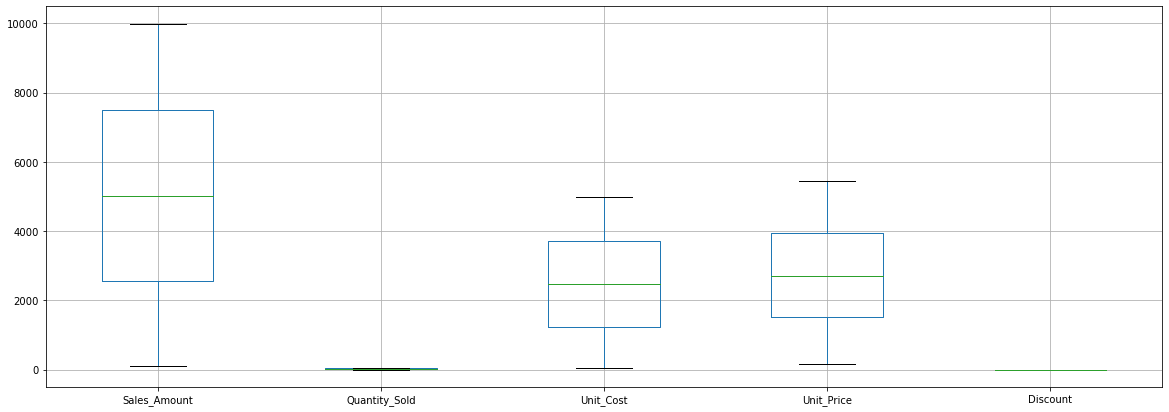

In [15]:
# Checking for outliers in variables using box plots
df.boxplot(column=['Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 
    'Discount'], figsize=(20,7))
plt.show()

### 4. Feature Engineering
- Converted the `Sale_Date` column to **datetime format**.
- Created new time-based features:
  - `year`
  - `month`
  - `day`
- Calculated additional business metrics:
  - **Profit**
  - **Revenue after discount**

In [16]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

### creating New Features like year,month and day.

In [17]:
df['year'] = df['Sale_Date'].dt.year
df['month'] = df['Sale_Date'].dt.month
df['day'] = df['Sale_Date'].dt.day

In [18]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,year,month,day
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2023,2,3
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,2023,4,21
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,2023,9,21
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,2023,8,24
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,2023,3,24


In [19]:
df.duplicated().sum()

0

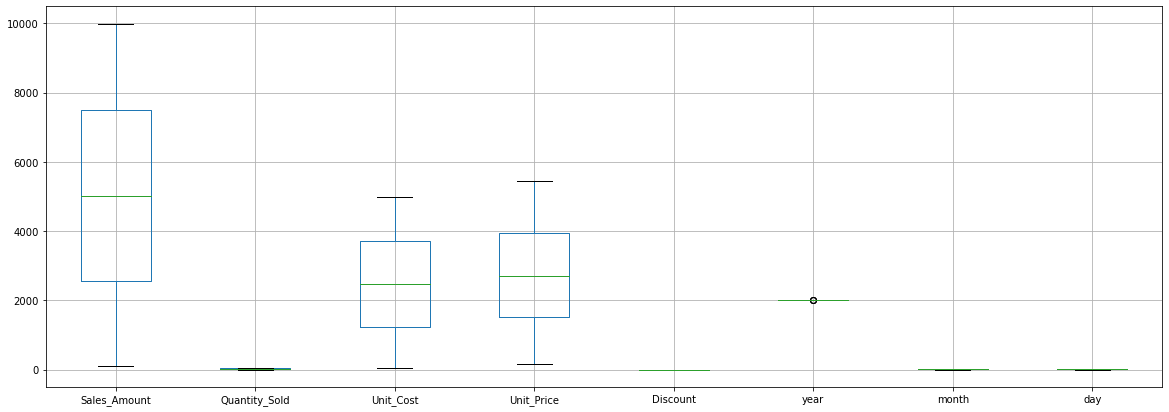

In [20]:
# Checking for outliers in variables using box plots
df.boxplot(column=['Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 
    'Discount', 'year', 'month', 'day'], figsize=(20,7))
plt.show()

In [21]:
#Dealing the year by removing the outliers.
Q1 = df['year'].quantile(0.25)
Q3 = df['year'].quantile(0.75)
IQR = Q3-Q1

In [22]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower = df['year'] < lower_bound
upper = df['year'] > upper_bound
print('Upper outliers of the year: ',upper.sum())
print('lower outliers of the year: ',lower.sum())

Upper outliers of the year:  3
lower outliers of the year:  0


In [23]:
# Removing the upper outliers.
df = df[~(df['year'] > upper_bound)]

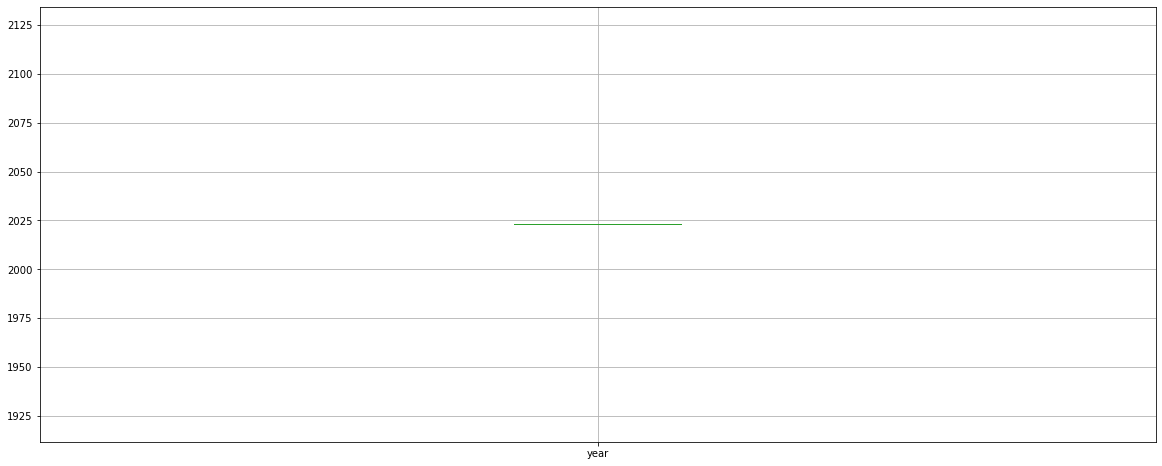

In [24]:
# Checking for outliers in year variables using box plots
df.boxplot(column=['year'], figsize=(20,8))
plt.show()

In [25]:
df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']

#### Discount impact:

In [26]:
df['Revenue_after_discount'] = df['Sales_Amount'] * (1 - df['Discount'])

### 5. Exploratory Data Analysis (EDA)
- Calculated **total sales**.
- Analyzed **sales by region**.
- Examined **sales by product category**.
- Studied **monthly sales trends**.
- Evaluated **sales representative performance**.

#### Total Sales

In [27]:
df['Sales_Amount'].sum()

4999937.22

#### Sales by Region

In [28]:
df.groupby('Region')['Sales_Amount'].sum().sort_values()

Region
South    1151880.14
West     1227029.21
East     1251415.36
North    1369612.51
Name: Sales_Amount, dtype: float64

### Regional Sales Performance
The **North region** generated the highest total sales among all regions, indicating strong market demand and higher revenue contribution from this area.


#### Sales by Product Category

In [29]:
df.groupby('Product_Category')['Sales_Amount'].sum()

Product_Category
Clothing       1311103.64
Electronics    1234919.92
Food           1193395.97
Furniture      1260517.69
Name: Sales_Amount, dtype: float64

### Product Category Performance
The **Furniture category** produced the highest overall profit, making it the most profitable product category in the dataset.


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Furniture'),
  Text(1, 0, 'Food'),
  Text(2, 0, 'Clothing'),
  Text(3, 0, 'Electronics')])

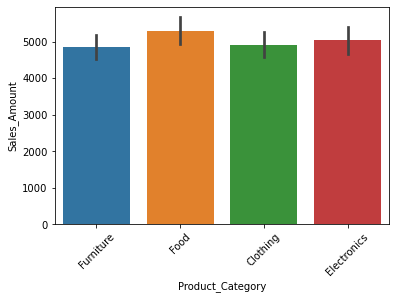

In [35]:
import seaborn as sns
sns.barplot(x='Product_Category', y='Sales_Amount', data=df)
plt.xticks(rotation=45)

#### Monthly Sales Trend

In [36]:
monthly_sales = df.groupby('month')['Sales_Amount'].sum()

<AxesSubplot:xlabel='month'>

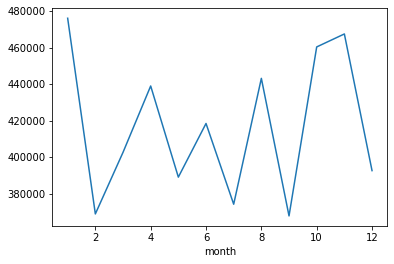

In [37]:
monthly_sales.plot(kind='line')

#### Best Sales Rep

In [38]:
df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False)

Sales_Rep
David      1133359.79
Bob        1078619.91
Eve         970183.99
Alice       956962.05
Charlie     860811.48
Name: Sales_Amount, dtype: float64

### Sales Representative Performance
Among all sales representatives, **David achieved the highest total sales**, demonstrating the strongest sales performance.


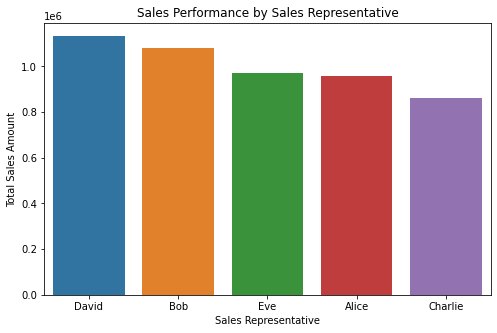

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sales_rep = df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=sales_rep.index, y=sales_rep.values)

plt.title("Sales Performance by Sales Representative")
plt.xlabel("Sales Representative")
plt.ylabel("Total Sales Amount")

plt.show()

<AxesSubplot:xlabel='Sales_Rep'>

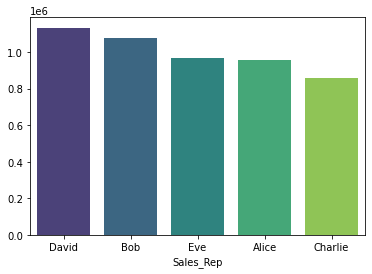

In [47]:
sns.barplot(x=sales_rep.index, y=sales_rep.values, palette="viridis")

### 6. Business Insights
- Investigated **customer type behavior**.
- Examined **payment method distribution**.
- Analyzed **discount impact on sales**.
- Compared **profit across product categories**.
- Compared **performance of online vs retail sales channels**.

## Payment Method Analysis

In [39]:
df.groupby('Payment_Method')['Sales_Amount'].sum()

Payment_Method
Bank Transfer    1706412.73
Cash             1535960.97
Credit Card      1757563.52
Name: Sales_Amount, dtype: float64

### Payment Method Trends
**Credit card payments were the most frequently used payment method**, suggesting a strong preference for digital payment options.


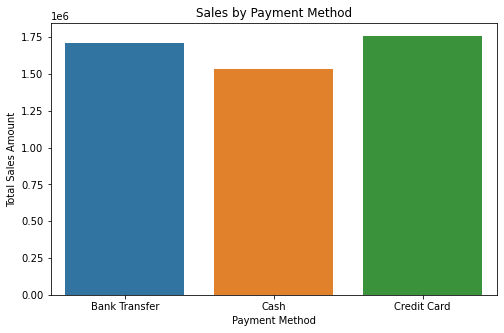

In [45]:
payment = df.groupby('Payment_Method')['Sales_Amount'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=payment.index, y=payment.values)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales Amount")

plt.show()

<AxesSubplot:xlabel='Payment_Method'>

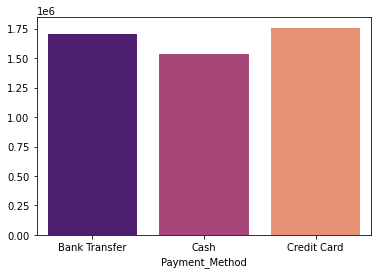

In [48]:
sns.barplot(x=payment.index, y=payment.values, palette="magma")

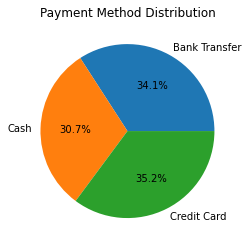

In [49]:
payment.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

### Customer Type Analysis

In [40]:
df.groupby('Customer_Type')['Sales_Amount'].sum()

Customer_Type
New          2497678.58
Returning    2502258.64
Name: Sales_Amount, dtype: float64

### Customer Behavior
**Returning customers generated slightly higher revenue than new customers**, highlighting the importance of customer retention strategies.

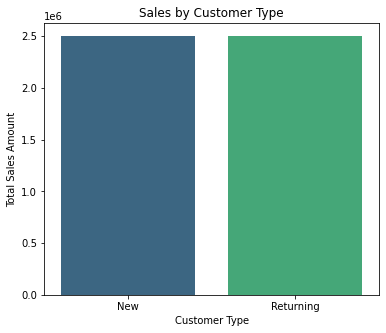

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

customer_sales = df.groupby('Customer_Type')['Sales_Amount'].sum()

plt.figure(figsize=(6,5))

sns.barplot(
    x=customer_sales.index,
    y=customer_sales.values,
    palette="viridis"
)

plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales Amount")

plt.show()

### Discount vs Sales

<AxesSubplot:xlabel='Discount', ylabel='Sales_Amount'>

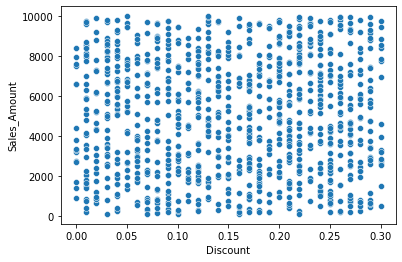

In [41]:
sns.scatterplot(x='Discount', y='Sales_Amount', data=df)

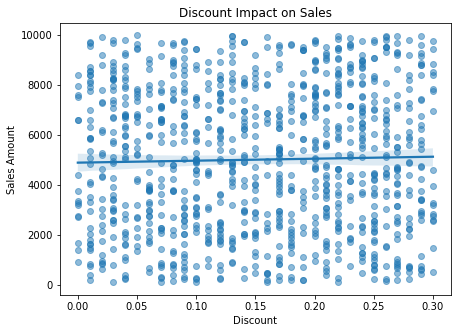

In [51]:
plt.figure(figsize=(7,5))

sns.regplot(
    x='Discount',
    y='Sales_Amount',
    data=df,
    scatter_kws={"alpha":0.5}
)

plt.title("Discount Impact on Sales")
plt.xlabel("Discount")
plt.ylabel("Sales Amount")

plt.show()

In [52]:
df[['Discount','Sales_Amount']].corr()

,Discount,Sales_Amount
Discount,1.000000,0.024211
Sales_Amount,0.024211,1.000000


### Discount Impact on Sales
The correlation between **discount and sales amount is extremely weak (0.02)**, indicating that discount levels do not significantly influence sales performance in this dataset.


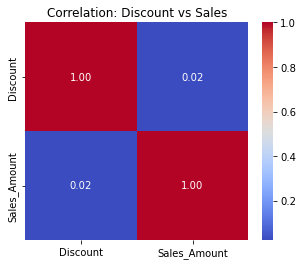

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['Discount','Sales_Amount']].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation: Discount vs Sales")

plt.show()

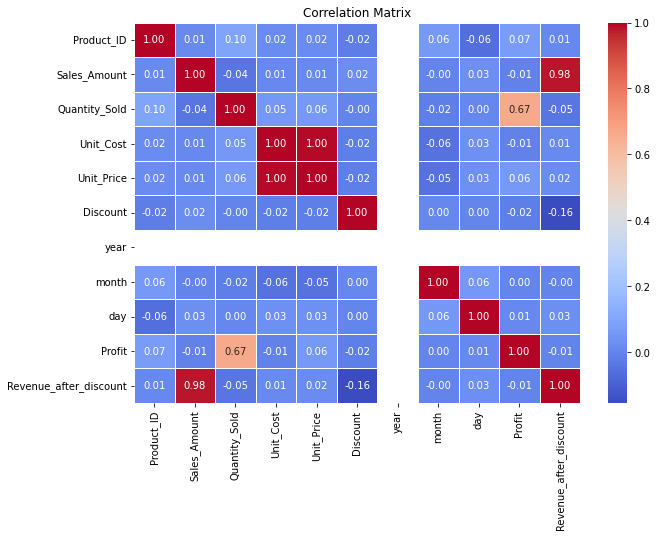

In [56]:
plt.figure(figsize=(10,7))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

### Profit by Product Category

In [42]:
df.groupby('Product_Category')['Profit'].sum()

Product_Category
Clothing       1709768.35
Electronics    1565511.34
Food           1410544.21
Furniture      1779461.16
Name: Profit, dtype: float64

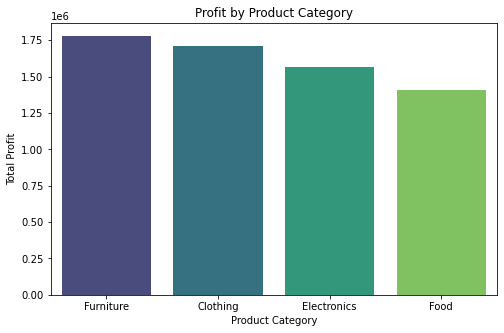

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

profit_cat = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_cat.index,
    y=profit_cat.values,
    palette="viridis"
)

plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")

plt.show()

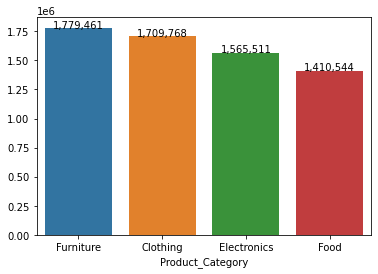

In [60]:
ax = sns.barplot(x=profit_cat.index, y=profit_cat.values)

for i, v in enumerate(profit_cat.values):
    ax.text(i, v, f"{v:,.0f}", ha='center')

plt.show()

### Channel Performance

In [43]:
df.groupby('Sales_Channel')['Sales_Amount'].sum()

Sales_Channel
Online    2447883.49
Retail    2552053.73
Name: Sales_Amount, dtype: float64

### Sales Channel Performance
**Retail sales slightly outperformed online sales**, although both channels contribute significantly to overall revenue.

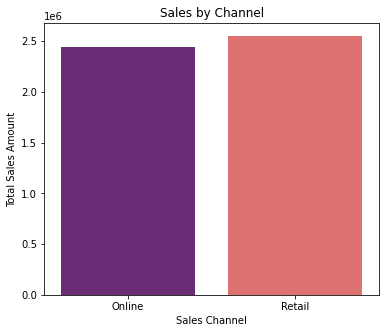

In [59]:
channel_sales = df.groupby('Sales_Channel')['Sales_Amount'].sum()

plt.figure(figsize=(6,5))

sns.barplot(
    x=channel_sales.index,
    y=channel_sales.values,
    palette="magma"
)

plt.title("Sales by Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Sales Amount")

plt.show()

## Business Recommendations

Based on the findings from the exploratory data analysis, the following recommendations can help improve business performance and strategic decision-making.

### 1. Focus on High-Profit Categories
Businesses should prioritize products in the **Furniture category**, as it generates the highest overall profit in the dataset. Increasing inventory and marketing efforts for these products could further boost profitability.

### 2. Strengthen Customer Retention
Returning customers contribute significantly to total revenue. Implementing **loyalty programs, personalized marketing, and customer engagement strategies** can help increase repeat purchases.

### 3. Optimize Discount Strategies
Since the analysis shows that **discounts have minimal impact on sales**, businesses should reassess discount policies to avoid unnecessary reductions in revenue.

### 4. Improve Sales Representative Performance
Sales representatives with lower performance levels could benefit from **additional training, performance incentives, and improved sales strategies**.

### 5. Expand High-Performing Regions
Regions with strong sales performance should receive **additional marketing investment, product availability, and operational focus** to further increase sales.

### 6. Maintain Multi-Channel Sales Strategy
Both **online and retail channels** contribute significantly to overall sales. Businesses should continue investing in both channels to maximize market reach and customer accessibility.

## Project Conclusion

This project analyzed retail sales data to identify patterns in sales performance, customer behavior, and product profitability.

Through **data cleaning, feature engineering, and exploratory data analysis**, several meaningful insights were discovered regarding the factors that influence revenue generation.

The analysis indicates that **product category and regional demand have a stronger impact on sales performance than discount levels**. In particular, the **Furniture category generated the highest profit**, making it the most valuable product segment in the dataset.

Additionally, **customer retention plays an important role in revenue generation**, as returning customers slightly outperform new customers in total sales.

Overall, these findings provide valuable insights that can support better **business decision-making, strategic planning, and sales optimization across different regions, product categories, and sales channels**.